In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

def plot_optimal_truncation(data, rho):
    data = np.asarray(data)

    # --------- Fonctions de perte ---------
    def loss_quadratic(U):
        excess = data[data > U] - U
        return excess.sum()**2 + U**2 / (2 * rho)

    def loss_absolute(U):
        excess = data[data > U] - U
        return excess.sum() + U**2 / (2 * rho)

    # --------- Optimisations ---------
    res_quad = minimize_scalar(loss_quadratic, bounds=(0, np.max(data)), method='bounded')
    res_abs = minimize_scalar(loss_absolute, bounds=(0, np.max(data)), method='bounded')
    U_quad, U_abs = res_quad.x, res_abs.x
    alpha_quad = np.mean(data <= U_quad)
    alpha_abs = np.mean(data <= U_abs)

    # --------- Comptages ---------
    n_above_U_quad = np.sum(data >= U_quad)
    n_above_U_abs = np.sum(data >= U_abs)

    # --------- Histogramme (mêmes bins pour les 2) ---------
    bin_heights, bin_edges = np.histogram(data, bins=40)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    width = bin_edges[1] - bin_edges[0]

    # --------- Affichage ---------
    fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, U_opt, alpha, title in zip(
        axs,
        [U_quad, U_abs],
        [alpha_quad, alpha_abs],
        ["Erreur quadratique (biais²)", "Erreur absolue (biais)"]
    ):
        # Couleurs selon seuil
        bar_colors = ["lightcoral" if center <= U_opt else "royalblue" for center in bin_centers]
        ax.bar(bin_centers, bin_heights / bin_heights.sum() * 100, width=width,
               color=bar_colors, edgecolor='black')

        # Ligne verticale + annotation
        ax.axvline(U_opt, color="black", linestyle="--", linewidth=1.5)
        ax.text(U_opt + 0.5, ax.get_ylim()[1] * 0.9,
                fr"$U = q_{{{alpha:.3f}}} \approx {U_opt:.2f}$",
                color="black", fontsize=12, va='top')

        ax.set_title(title)
        ax.set_xlabel("Valeur")
        ax.grid(True)

    axs[0].set_ylabel("Pourcentage")

    plt.tight_layout()
    plt.show()

    return {
        "U_quadratique": U_quad,
        "alpha_quadratique": alpha_quad,
        "n_sup_ou_egal_U_quadratique": int(n_above_U_quad),
        "U_absolue": U_abs,
        "alpha_absolue": alpha_abs,
        "n_sup_ou_egal_U_absolue": int(n_above_U_abs)
    }


# Loi simulée

## Normal

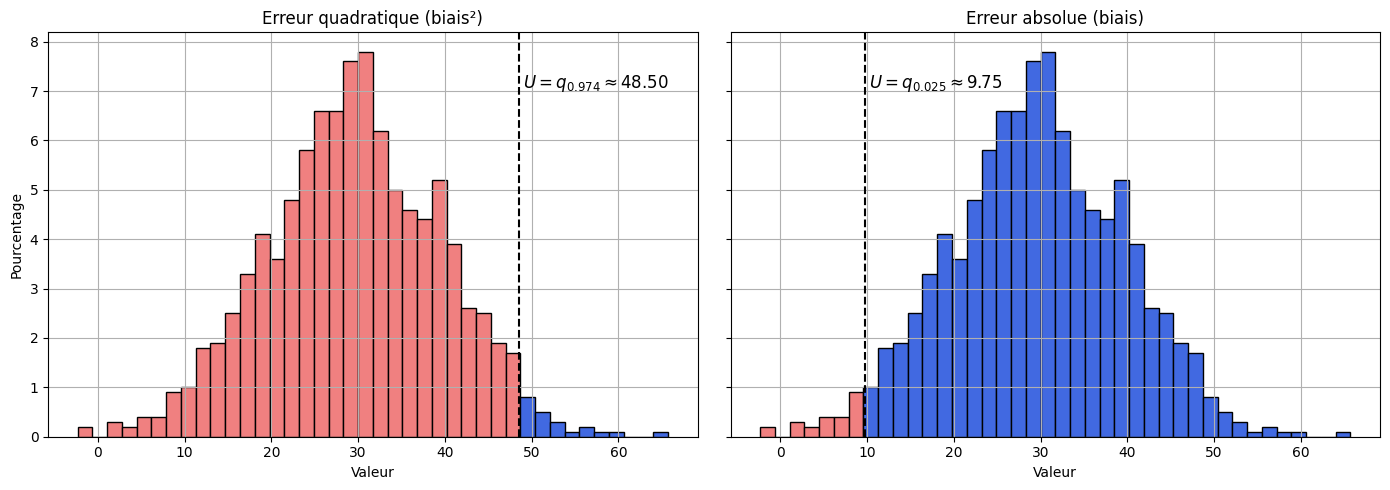

{'U_quadratique': np.float64(48.499811318785696), 'alpha_quadratique': np.float64(0.974), 'n_sup_ou_egal_U_quadratique': 26, 'U_absolue': np.float64(9.75000000001909), 'alpha_absolue': np.float64(0.025), 'n_sup_ou_egal_U_absolue': 975}


In [12]:
np.random.seed(123)
data = np.random.normal(loc=30, scale=10, size=1000)
rho = 0.01

res = plot_optimal_truncation(data, rho)
print(res)

## Exponentielle

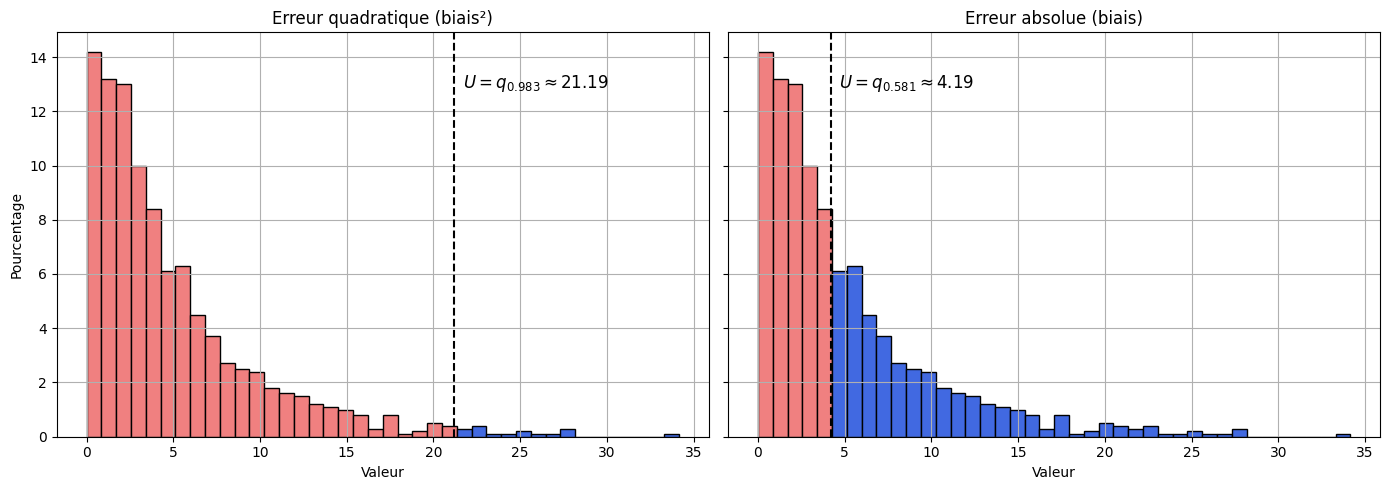

{'U_quadratique': np.float64(21.188694682595607), 'alpha_quadratique': np.float64(0.983), 'n_sup_ou_egal_U_quadratique': 17, 'U_absolue': np.float64(4.189999999998767), 'alpha_absolue': np.float64(0.581), 'n_sup_ou_egal_U_absolue': 419}


In [13]:
np.random.seed(123)
data = np.random.exponential(scale=5, size=1000)
rho = 0.01

res = plot_optimal_truncation(data, rho)
print(res)

## Log normal

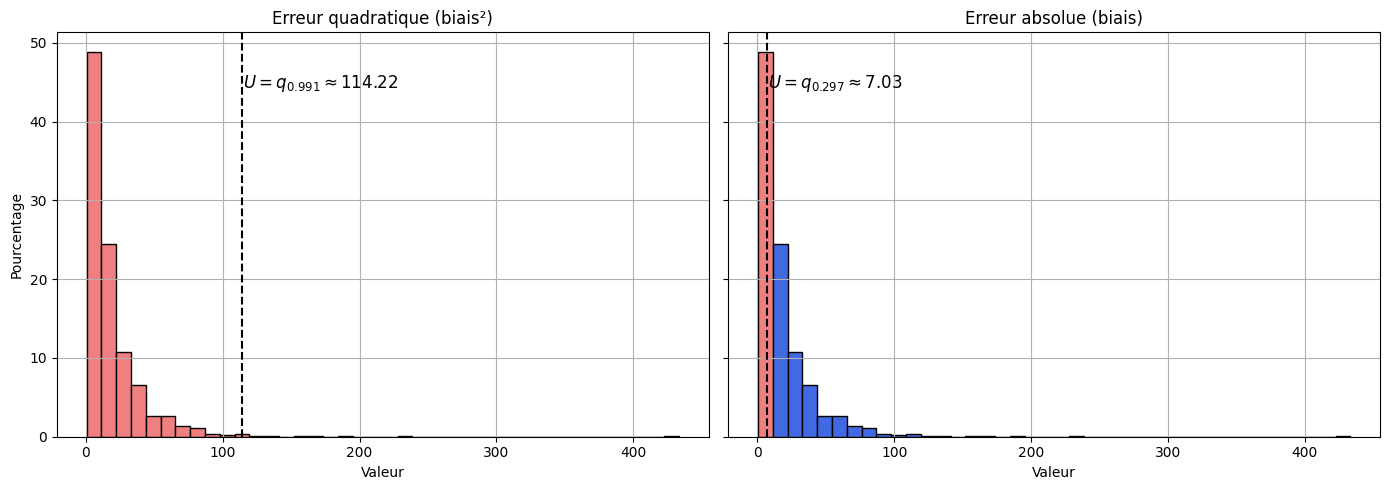

{'U_quadratique': np.float64(114.22193031754573), 'alpha_quadratique': np.float64(0.991), 'n_sup_ou_egal_U_quadratique': 9, 'U_absolue': np.float64(7.033937544168474), 'alpha_absolue': np.float64(0.297), 'n_sup_ou_egal_U_absolue': 703}


In [14]:
np.random.seed(123)
data = np.random.lognormal(mean=2.5, sigma=1.0, size=1000)
rho = 0.01

res = plot_optimal_truncation(data, rho)
print(res)

# Dataset penguins

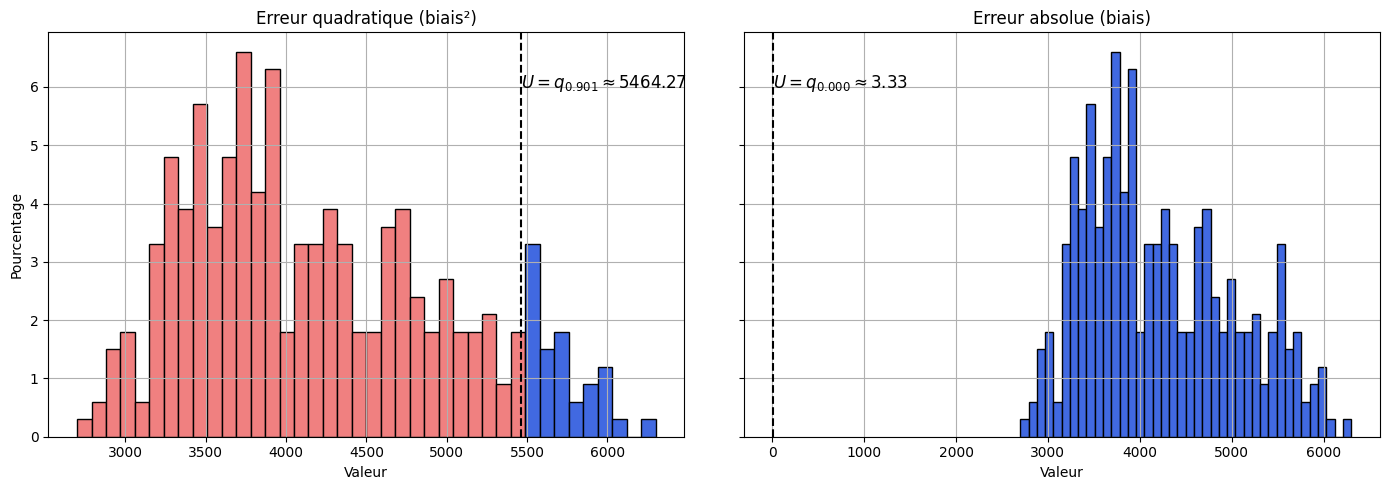

{'U_quadratique': np.float64(5464.2669007903), 'alpha_quadratique': np.float64(0.9009009009009009), 'n_sup_ou_egal_U_quadratique': 33, 'U_absolue': np.float64(3.3300000000025047), 'alpha_absolue': np.float64(0.0), 'n_sup_ou_egal_U_absolue': 333}


In [15]:
import seaborn as sns

np.random.seed(123)
data = sns.load_dataset("penguins").dropna()["body_mass_g"]
rho = 0.01

res = plot_optimal_truncation(data, rho)
print(res)

# Population metro

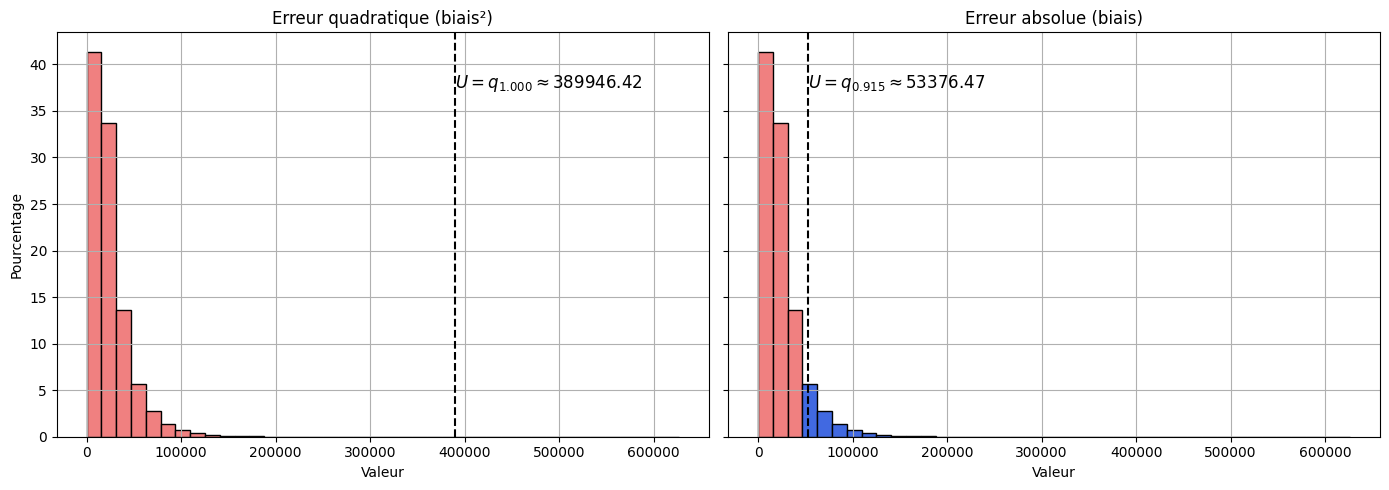

{'U_quadratique': np.float64(389946.41622607474), 'alpha_quadratique': np.float64(0.9999996823952783), 'n_sup_ou_egal_U_quadratique': 20, 'U_absolue': np.float64(53376.47000968147), 'alpha_absolue': np.float64(0.9152369054908076), 'n_sup_ou_egal_U_absolue': 5337647}
Le max du Niveau de vie : 626638.0824778209


In [ ]:
import polars as pl
import os 

storage_options = {
    "aws_access_key_id": os.environ["AWS_ACCESS_KEY_ID"],
    "aws_secret_access_key": os.environ["AWS_SECRET_ACCESS_KEY"],
    "aws_session_token": os.environ["AWS_SESSION_TOKEN"],
    "endpoint_url": "https://minio.lab.sspcloud.fr",
}

source = "s3://gferey/diffusion/synthetic-filo/METRO/population/population_METRO.parquet"

df = pl.read_parquet(source, storage_options=storage_options)
data = df["NIVEAU_VIE"]
rho = 0.01

res = plot_optimal_truncation(data, rho)
print(res)

print("Le max du Niveau de vie :", data.max())

## Autres critères (espérance, variance)

In [1]:
import pandas as pd
import numpy as np

def compute_bias_variance(y, rho, list_upper):
    """
    Compute total, biased total, bias, variance, and coefficient of variation for each upper bound.

    Parameters:
    - y (list or np.ndarray): List of values (original data)
    - rho (float): Privacy parameter
    - list_upper (list or np.ndarray): List of upper bounds to apply truncation

    Returns:
    - pd.DataFrame: A DataFrame with columns:
        ['upper', 'true_total', 'clipped_total', 'bias', 'variance', 'coef_var']
    """
    y = np.array(y)
    results = []

    for upper in list_upper:
        clipped_y = np.minimum(y, upper)
        true_total = np.sum(y)
        clipped_total = np.sum(clipped_y)
        bias = clipped_total - true_total
        variance = upper**2 / (2 * rho)
        std_dev = np.sqrt(variance)
        coef_var = std_dev / clipped_total if clipped_total != 0 else np.nan

        results.append({
            'upper': upper,
            'true_total': true_total,
            'clipped_total': clipped_total,
            'bias': bias,
            'variance': variance,
            'coef_var': coef_var
        })

    return pd.DataFrame(results)


In [ ]:
import polars as pl
import os

storage_options = {
    "endpoint_url": "https://minio.lab.sspcloud.fr",
}

source = "s3://gferey/diffusion/synthetic-filo/METRO/population/population_METRO.parquet"

df = pl.read_parquet(source, storage_options=storage_options)
data = df["NIVEAU_VIE"]
rho = 0.01
list_upper = [data.max()]

print(compute_bias_variance(data, rho, list_upper))

OSError: object-store error: Generic S3 error: Error performing PUT http://169.254.169.254/latest/api/token in 3.251644261s, after 2 retries, max_retries: 2, retry_timeout: 10s  - HTTP error: error sending request

This error occurred with the following context stack:
	[1] 'parquet scan'
	[2] 'sink'
